# 29 - DE sink: background, CMB and P(k)

Compares accDM with `acc_de_sink` off and on, and both against ΛCDM, over a mass scan with the
default kick η = 10¹¹ GeV / m_acc. The sink is a w = −1 component that pays the daughters' kick
energy, so it is larger in the past: ρ_de_acc(a) = η f_acc ρ_cdm,0 J(a), with J(0) ≈ 471 for
κ = 12.1, a_t = 0.133.

`FIX` selects what is held fixed between runs: `'100*theta_s'` (H0 is solved by shooting, closest
to what a fit sees) or `'H0'` (the peak shift from the changed sound horizon then dominates ΔC_ℓ).

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

import figkit as fk
import tqdm as tqdm

fk.use('quick')

FIX = '100*theta_s'                       # or 'H0'
THETA_S, H0 = 1.041783, 67.32
BASE = {'omega_b': 0.022383, 'A_s': 2.1005829616811546e-9, 'n_s': 0.96605,
        'tau_reio': 0.0543, 'N_ur': 0.00441}
OMEGA_CDM0 = 0.12011
A_REC = 1.0/1091.0

MASSES = [1e11, 1e12, 1e13, 1e16]         # GeV; eta = 1e11/m
F_ACC, KAPPA, A_T = 0.1, 12.1, 0.133
N_Q = 51                                  # qm_acc_birth daughter bins (odd)
L_MAX = 2500
K = np.logspace(-4, np.log10(5.0), 300)   # 1/Mpc

# rk evolver (ndf15 cannot handle the daughter hierarchy); exact ncdm hierarchy
COMMON = {'output': 'tCl,pCl,lCl,mPk', 'lensing': 'yes', 'l_max_scalars': L_MAX,
          'P_k_max_1/Mpc': 10.0, 'z_max_pk': 0.0,
          'gauge': 'synchronous', 'evolver': 0, 'ncdm_fluid_approximation': 3}


def fixed():
    return {FIX: THETA_S if FIX == '100*theta_s' else H0}


def lcdm_params():
    return {**BASE, **COMMON, **fixed(), 'omega_cdm': OMEGA_CDM0,
            'N_ncdm': 1, 'deg_ncdm': '3', 'm_ncdm': '0.02', 'T_ncdm': '0.71611',
            'ncdm_quadrature_strategy': '0', 'ncdm_N_momentum_bins': '15'}


def accdm_params(mass, sink):
    # omega_cdm rescaled so the total matter at recombination matches LCDM
    ocdm = OMEGA_CDM0/(1 + F_ACC*(1 - A_REC**KAPPA)/(1 + (A_REC/A_T)**KAPPA))
    return {**BASE, **COMMON, **fixed(), 'omega_cdm': ocdm,
            'vary_Gamma_acc': 'yes', 'kappa_acc': KAPPA, 'a_t_acc': A_T,
            'f_acc': F_ACC, 'eta_acc': 1e11/mass,
            'm_acc_in_GeV': mass, 'm_cdm_in_GeV': mass,
            'N_ncdm': 2, 'deg_ncdm': '3, 1', 'm_ncdm': '0.02, {:.6e}'.format(mass*1e9),
            'T_ncdm': '0.71611, 1', 'ncdm_quadrature_strategy': '0, 5',
            #'ncdm_N_momentum_bins': '15, {:d}'.format(N_Q),
            'acc_de_sink': 'yes' if sink else 'no'}


def run(params):
    cosmo = Class()
    cosmo.set(params)
    try:
        cosmo.compute()
        out = dict(bg=cosmo.get_background(), cl=cosmo.lensed_cl(L_MAX),
                   pk=np.array([cosmo.pk(k, 0.0) for k in K]))
        out.update(cosmo.get_current_derived_parameters(['h', '100*theta_s', 'sigma8']))
    finally:
        cosmo.struct_cleanup()
        cosmo.empty()
    return out


def sorted_bg(bg):
    """Background columns sorted by increasing a."""
    a = 1.0/(1.0 + np.asarray(bg['z']))
    order = np.argsort(a)
    return a[order], {key: np.asarray(val)[order] for key, val in bg.items()}


print('FIX = {}, masses = {}'.format(FIX, MASSES))

FIX = 100*theta_s, masses = [100000000000.0, 1000000000000.0, 10000000000000.0, 1e+16]


In [5]:
runs = {'lcdm': run(lcdm_params())}
for m in tqdm.tqdm(MASSES):
    for sink in (False, True):
        try:
            runs[(m, sink)] = run(accdm_params(m, sink))
        except Exception as err:
            print('m = {:.0e} GeV, sink {}: FAILED - {}'.format(m, 'on' if sink else 'off', err))
ok = [m for m in MASSES if (m, False) in runs and (m, True) in runs]
print('completed masses:', ['{:.0e}'.format(m) for m in ok])

100%|██████████| 4/4 [02:43<00:00, 40.97s/it]

completed masses: ['1e+11', '1e+12', '1e+13', '1e+16']


In [6]:
# Sanity: the toggle works, and a negligible sink (heaviest mass) changes nothing.
m_ref = max(ok)
off, on = runs[(m_ref, False)], runs[(m_ref, True)]
assert '(.)rho_de_acc' in on['bg'] and '(.)rho_de_acc' not in off['bg']
d_tt = float(np.max(np.abs(on['cl']['tt'][2:]/off['cl']['tt'][2:] - 1)))
d_pk = float(np.max(np.abs(on['pk']/off['pk'] - 1)))
print('m = {:.0e} GeV (eta = {:.0e}): max|dTT/TT| = {:.1e}, max|dP/P| = {:.1e}'.format(
    m_ref, 1e11/m_ref, d_tt, d_pk))
assert max(d_tt, d_pk) < 1e-3, 'negligible sink changed the spectra'

m = 1e+16 GeV (eta = 1e-05): max|dTT/TT| = 6.0e-06, max|dP/P| = 2.3e-07


## Background

Top: energy densities in units of today's critical density, sink on. Bottom: change in the
expansion rate from switching the sink on.

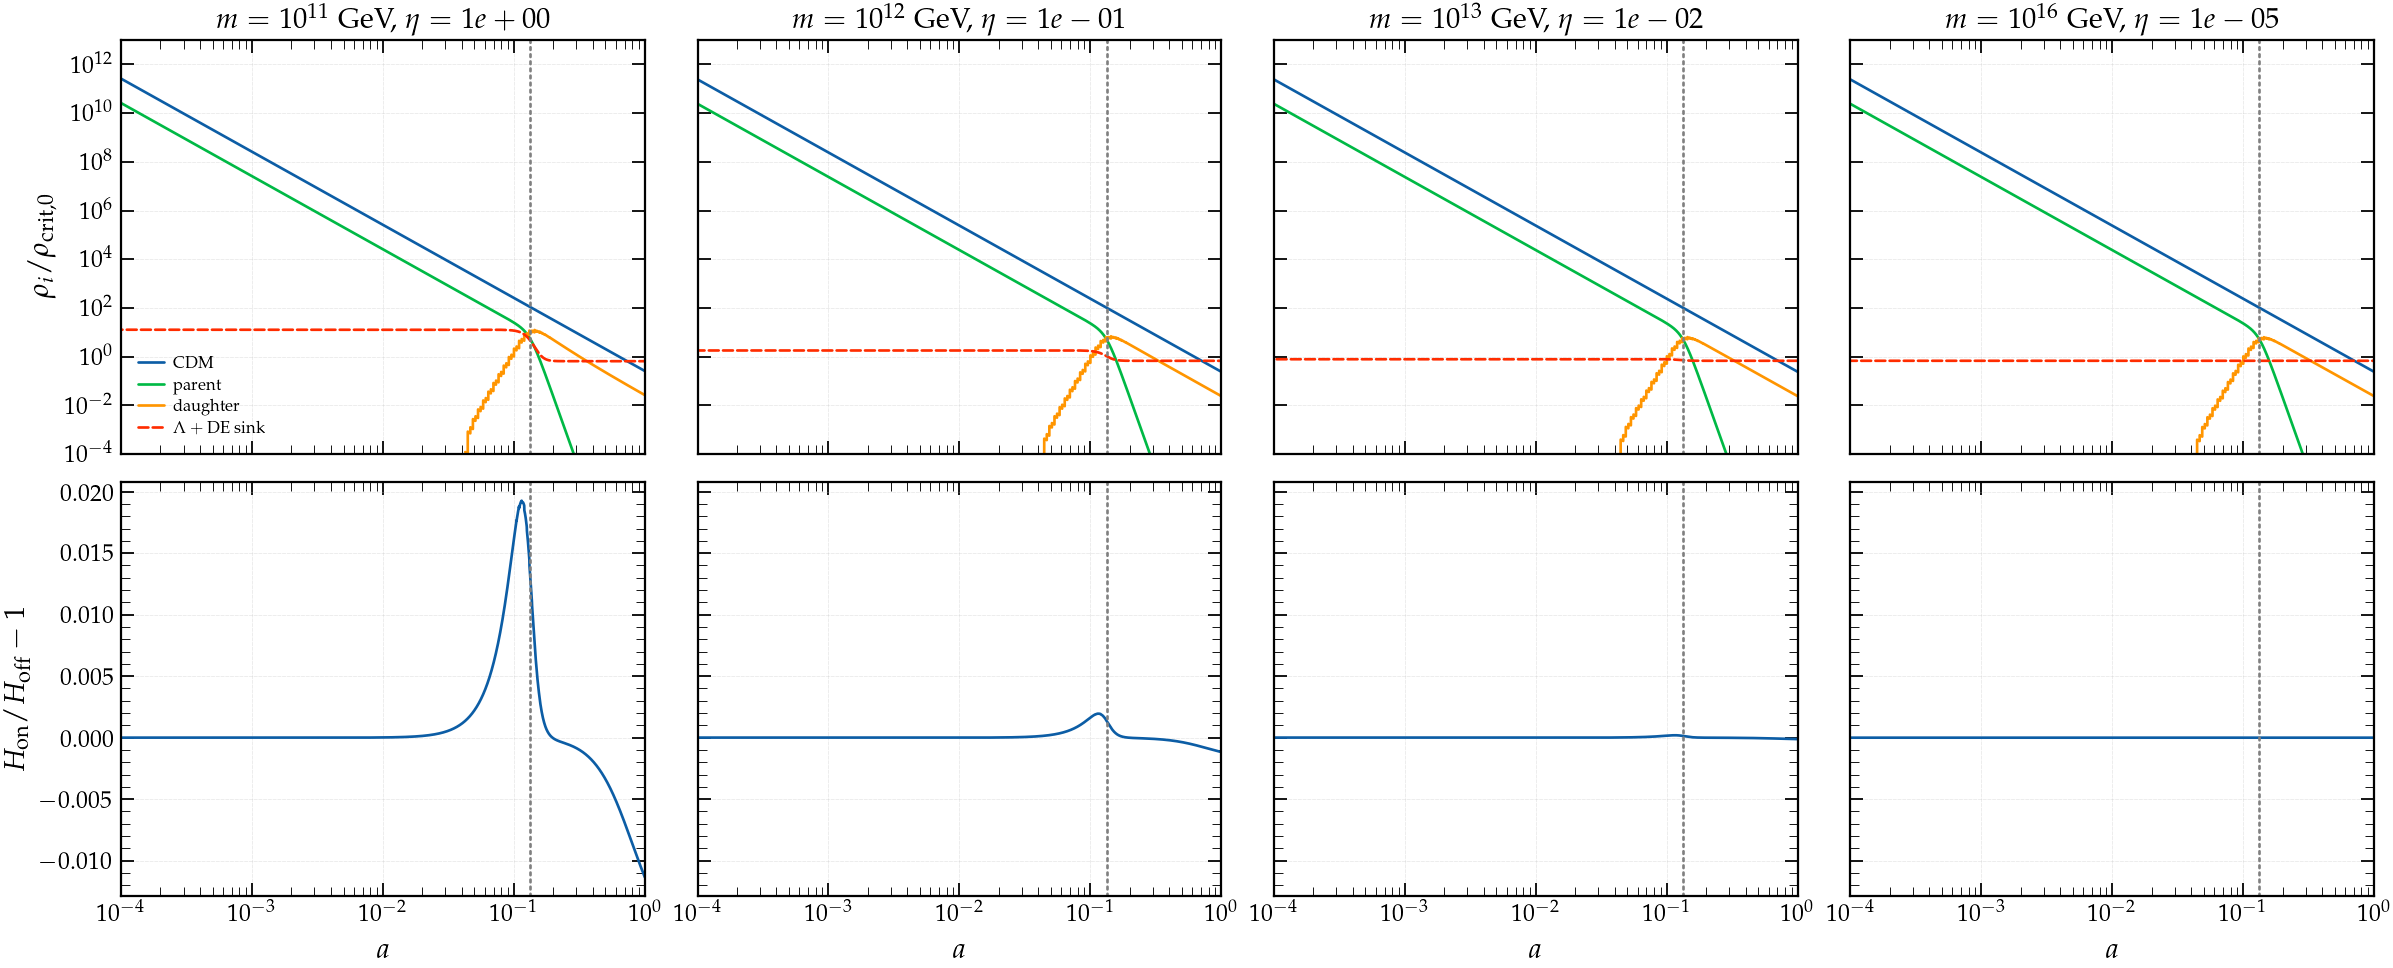

In [9]:
COMPONENTS = [('(.)rho_cdm', 'CDM'), ('(.)rho_acc_cdm', 'parent'), ('(.)rho_ncdm[1]', 'daughter'),
              ('(.)rho_lambda', r'$\Lambda$'), ('(.)rho_de_acc', 'DE sink')]

fig, axes = plt.subplots(2, len(ok), figsize=(4*len(ok), 6.5), sharex=True, sharey='row',
                         constrained_layout=True, squeeze=False)
for j, m in enumerate(ok):
    a, b = sorted_bg(runs[(m, True)]['bg'])
    a_off, b_off = sorted_bg(runs[(m, False)]['bg'])
    rho_crit0 = b['(.)rho_crit'][-1]
    ax = axes[0, j]
    for key, label in COMPONENTS:
        if key not in ['(.)rho_de_acc', '(.)rho_lambda']:
            ax.loglog(a, np.where(b[key] > 0, b[key], np.nan)/rho_crit0, label=label)
    
    ### Plot sum of lambda and DE sink as a single line
    ax.loglog(a, np.where(b['(.)rho_lambda'] + b['(.)rho_de_acc'] > 0, b['(.)rho_lambda'] + b['(.)rho_de_acc'], np.nan)/rho_crit0, label=r'$\Lambda + {\rm DE\ sink}$', color='C3', ls='--')
    
    ax.axvline(A_T, color='grey', ls=':')
    ax.set_title(r'$m = 10^{{{:.0f}}}$ GeV, $\eta = {:.0e}$'.format(np.log10(m), 1e11/m))
    ax.set_xlim(1e-4, 1)
    ax.set_ylim(1e-4, 1e13)
    ax.grid(alpha=0.3)
    ax = axes[1, j]
    H_off = np.interp(np.log(a), np.log(a_off), b_off['H [1/Mpc]'])
    ax.semilogx(a, b['H [1/Mpc]']/H_off - 1)
    ax.axvline(A_T, color='grey', ls=':')
    ax.set_xlabel(r'$a$')
    ax.grid(alpha=0.3)
axes[0, 0].set_ylabel(r'$\rho_i/\rho_{\rm crit,0}$')
axes[1, 0].set_ylabel(r'$H_{\rm on}/H_{\rm off} - 1$')
axes[0, 0].legend(fontsize=8)
plt.show()

## CMB

Relative differences in the lensed spectra. TE is normalised by √(C_ℓ^TT C_ℓ^EE) because it
crosses zero. Grey: cosmic variance √(2/(2ℓ+1)) per multipole.

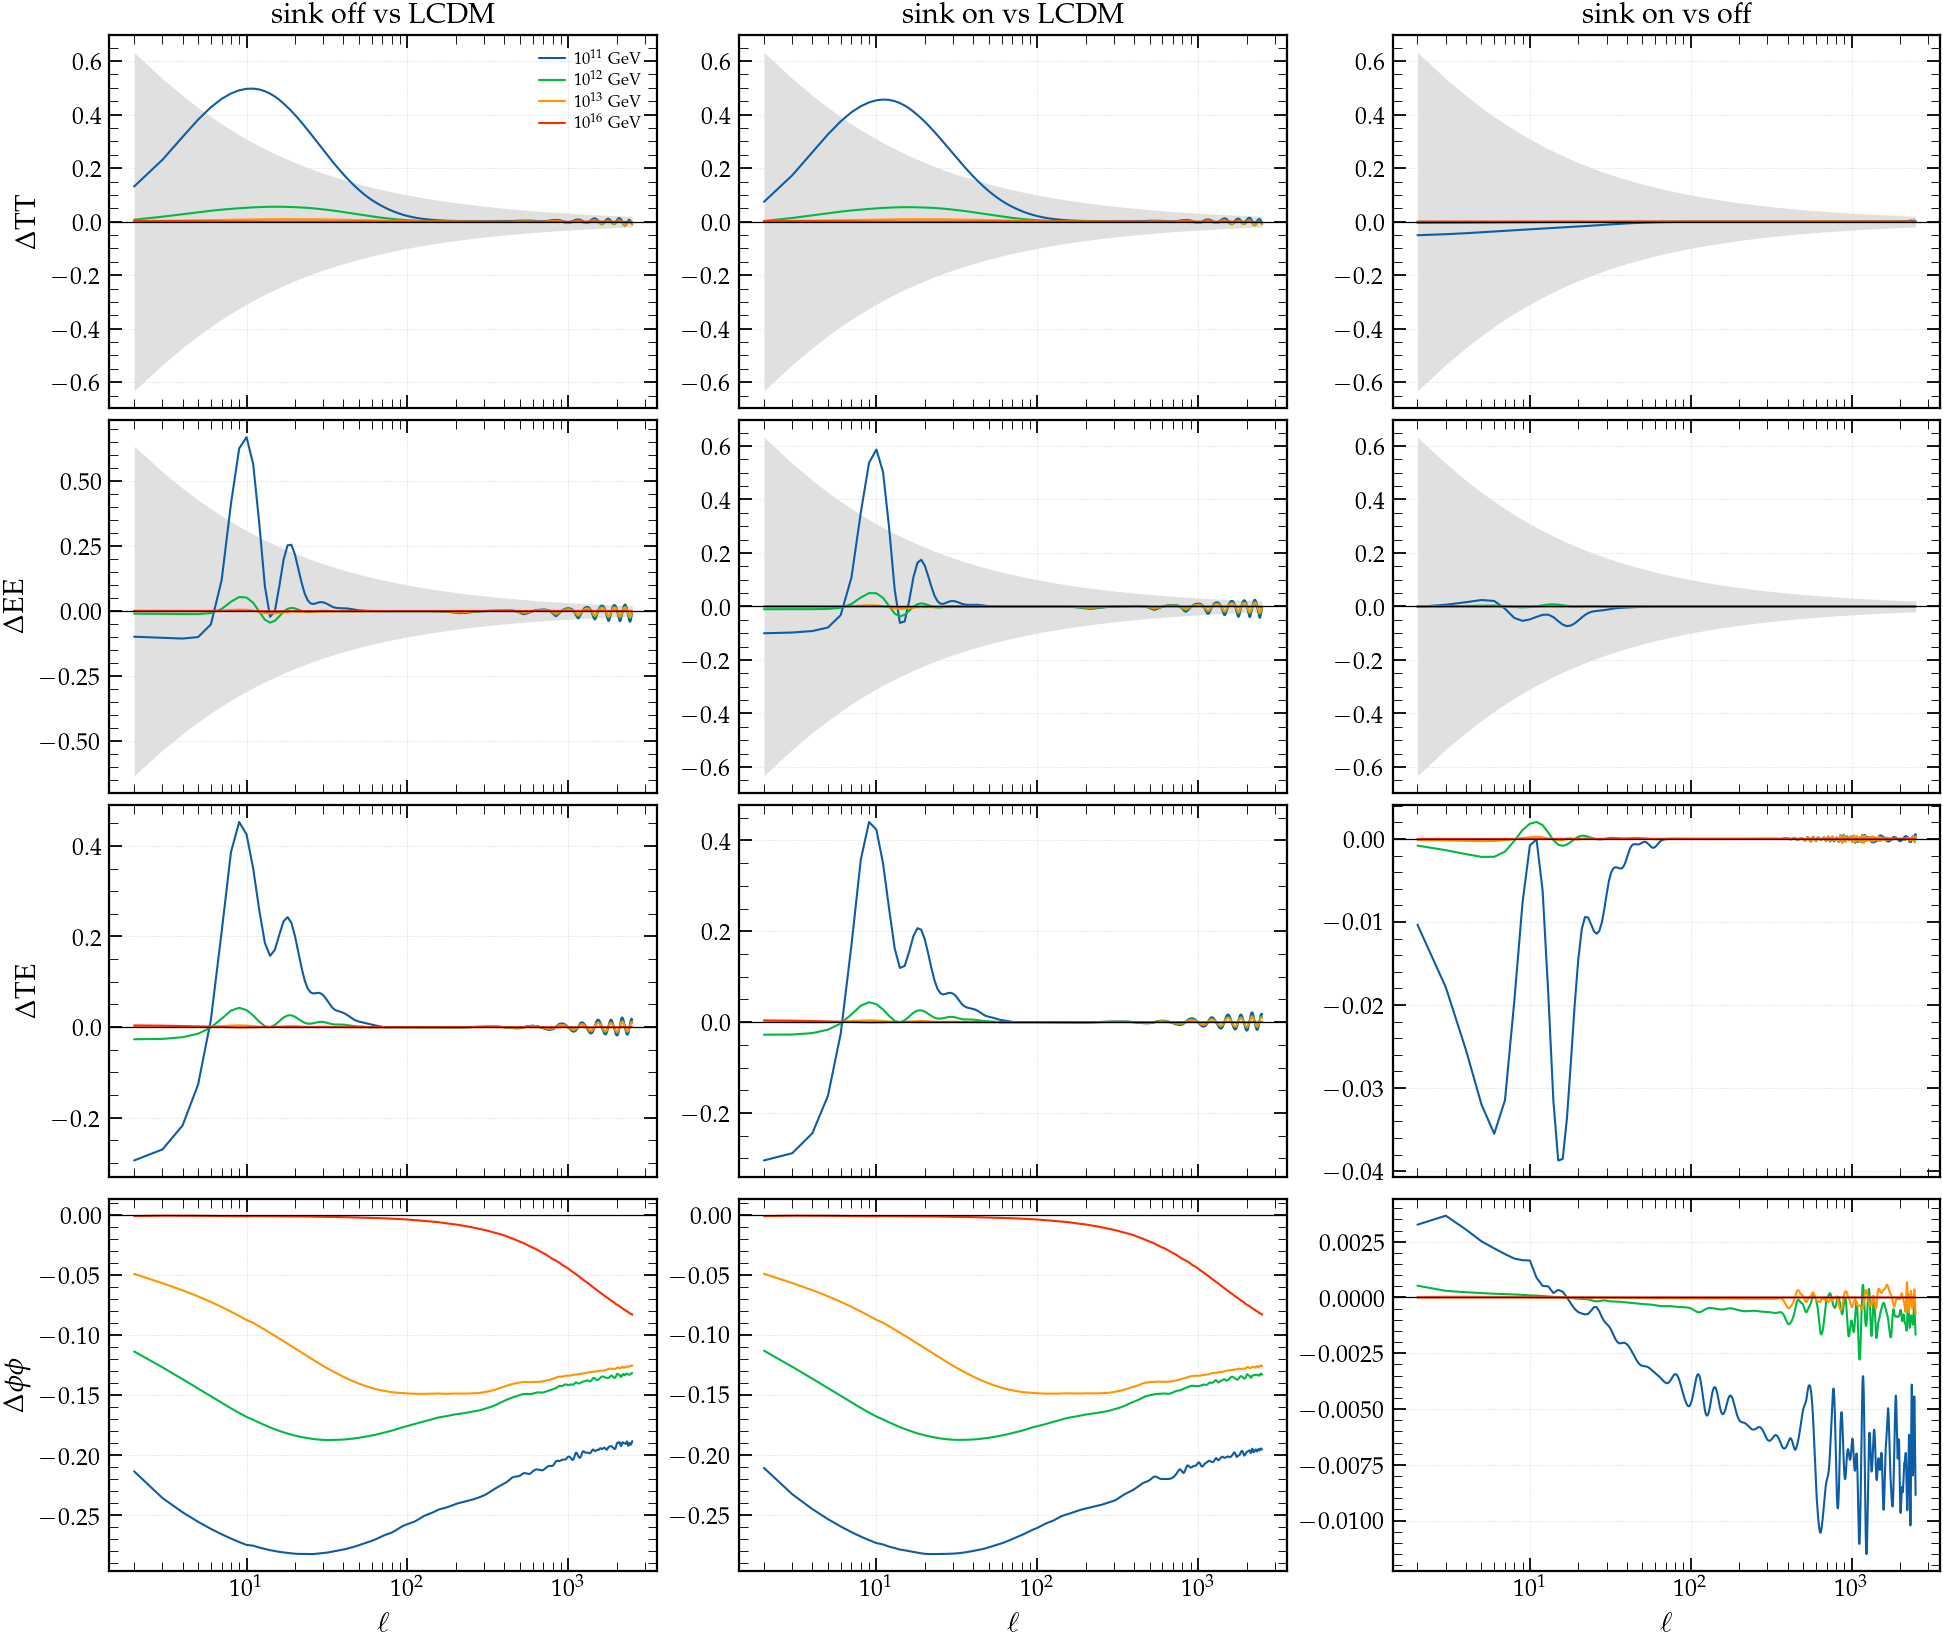

In [10]:
ell = runs['lcdm']['cl']['ell'][2:]
cv = np.sqrt(2.0/(2*ell + 1))


def cl(r, key):
    return r['cl'][key][2:]


def delta(x, y, key):
    if key == 'te':
        return (cl(x, 'te') - cl(y, 'te'))/np.sqrt(cl(y, 'tt')*cl(y, 'ee'))
    return cl(x, key)/cl(y, key) - 1


ROWS = [('tt', 'TT'), ('ee', 'EE'), ('te', 'TE'), ('pp', r'$\phi\phi$')]
COLS = [('sink off vs LCDM', lambda m: (runs[(m, False)], runs['lcdm'])),
        ('sink on vs LCDM', lambda m: (runs[(m, True)], runs['lcdm'])),
        ('sink on vs off', lambda m: (runs[(m, True)], runs[(m, False)]))]

fig, axes = plt.subplots(len(ROWS), len(COLS), figsize=(13, 11), sharex=True,
                         constrained_layout=True)
for i, (key, name) in enumerate(ROWS):
    for j, (title, pair) in enumerate(COLS):
        ax = axes[i, j]
        if key in ('tt', 'ee'):
            ax.fill_between(ell, -cv, cv, color='0.88', lw=0)
        for m in ok:
            ax.plot(ell, delta(*pair(m), key), lw=1,
                    label=r'$10^{{{:.0f}}}$ GeV'.format(np.log10(m)))
        ax.axhline(0, color='k', lw=0.6)
        ax.set_xscale('log')
        ax.grid(alpha=0.3)
        if i == 0:
            ax.set_title(title)
        if j == 0:
            ax.set_ylabel(r'$\Delta$' + name)
        if i == len(ROWS) - 1:
            ax.set_xlabel(r'$\ell$')
axes[0, 0].legend(fontsize=8)
plt.show()

## Matter power spectrum (z = 0)

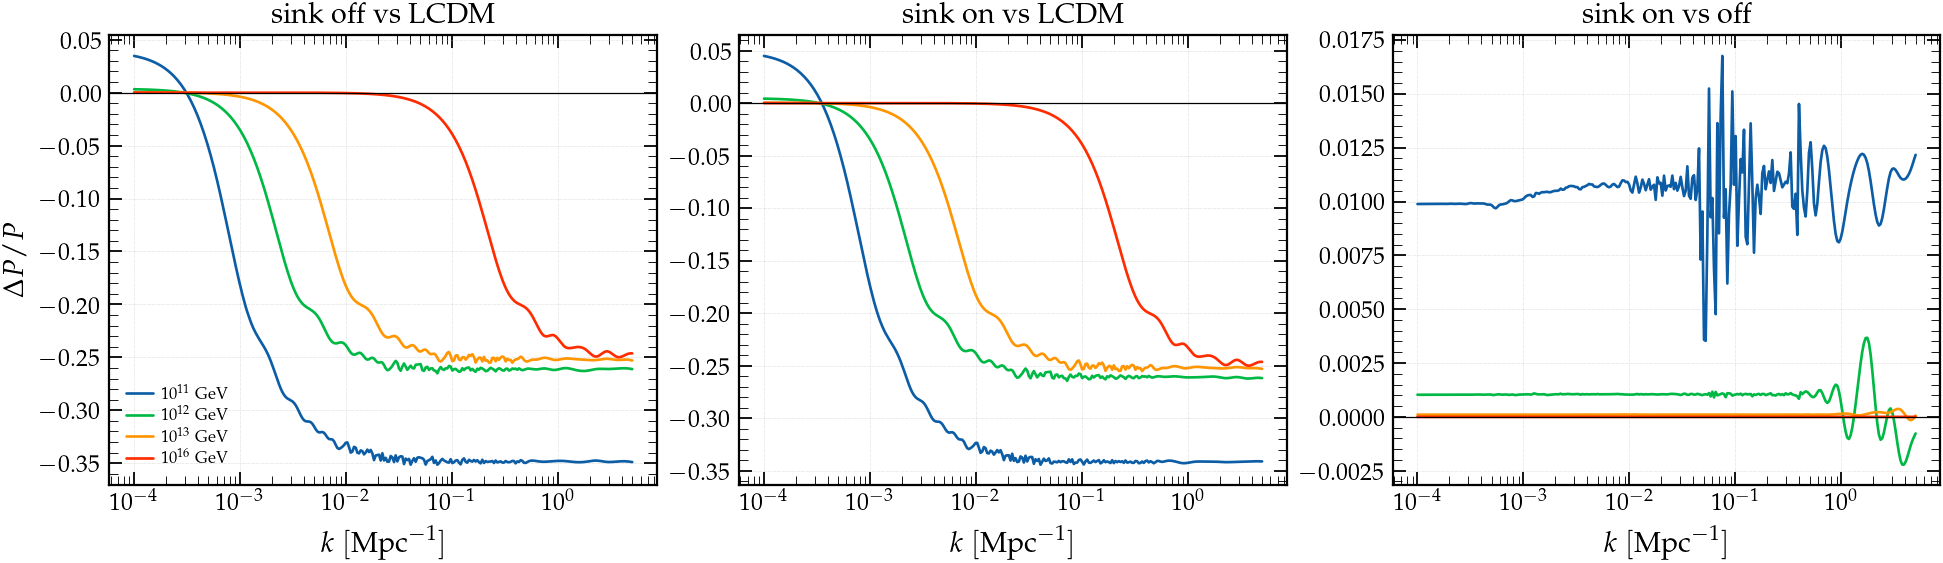

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True, constrained_layout=True)
p_ref = runs['lcdm']['pk']
for m in ok:
    label = r'$10^{{{:.0f}}}$ GeV'.format(np.log10(m))
    p_off, p_on = runs[(m, False)]['pk'], runs[(m, True)]['pk']
    axes[0].semilogx(K, p_off/p_ref - 1, label=label)
    axes[1].semilogx(K, p_on/p_ref - 1, label=label)
    axes[2].semilogx(K, p_on/p_off - 1, label=label)
for ax, title in zip(axes, ['sink off vs LCDM', 'sink on vs LCDM', 'sink on vs off']):
    ax.axhline(0, color='k', lw=0.6)
    ax.set_title(title)
    ax.set_xlabel(r'$k\ [\mathrm{Mpc}^{-1}]$')
    ax.grid(alpha=0.3)
axes[0].set_ylabel(r'$\Delta P/P$')
axes[0].legend(fontsize=8)
plt.show()

In [12]:
free = 'H0' if FIX == '100*theta_s' else '100*theta_s'
value = (lambda r: 100*r['h']) if free == 'H0' else (lambda r: r['100*theta_s'])

print('FIX = {}; LCDM: {} = {:.4f}, sigma8 = {:.4f}'.format(
    FIX, free, value(runs['lcdm']), runs['lcdm']['sigma8']))
print('{:>8} {:>8} {:>10} {:>10} {:>10} {:>8} {:>8} {:>10}'.format(
    'm [GeV]', 'eta', 'max Om_de', free + ' off', free + ' on', 's8 off', 's8 on', 'max dTT'))
for m in ok:
    off, on = runs[(m, False)], runs[(m, True)]
    _, b = sorted_bg(on['bg'])
    om_de = float(np.max(b['(.)rho_de_acc']))/b['(.)rho_crit'][-1]
    d_tt = float(np.max(np.abs(cl(on, 'tt')/cl(off, 'tt') - 1)))
    print('{:>8.0e} {:>8.0e} {:>10.2e} {:>10.4f} {:>10.4f} {:>8.4f} {:>8.4f} {:>10.2e}'.format(
        m, 1e11/m, om_de, value(off), value(on), off['sigma8'], on['sigma8'], d_tt))

FIX = 100*theta_s; LCDM: H0 = 67.3534, sigma8 = 0.8132
 m [GeV]      eta  max Om_de     H0 off      H0 on   s8 off    s8 on    max dTT
   1e+11    1e+00   1.23e+01    65.5350    64.7916   0.6444   0.6426   5.08e-02
   1e+12    1e-01   1.14e+00    67.1932    67.1149   0.6980   0.6978   4.88e-03
   1e+13    1e-02   1.14e-01    67.3377    67.3299   0.7051   0.7051   7.05e-04
   1e+16    1e-05   1.13e-04    67.3534    67.3534   0.7877   0.7877   6.02e-06
